# Step 1: Data Cleaning and Preprocessing

In this step, we focus on cleaning the raw dataset and preparing it for machine learning.

The dataset contains several real-world issues such as:
- Missing values
- Invalid zero values in medical features
- Outliers

Proper data cleaning is essential to improve model performance and reliability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Loading the Dataset

The dataset is loaded using pandas. We inspect the first few rows to understand the structure and column names.

In [3]:
data = pd.read_csv("raw_diabetes_data.csv")

In [4]:
data.head()

,Pregnancies,Glucose,Blood - Pressure,Skin - Thickness,Insulin,B M I,Diabetes Pedigree Function,Age,Outcome
0,6.0,144.0,71.0,18.0,85.0,28.6,2.370,61.0,NaN
1,3.0,198.0,67.0,8.0,100.0,22.1,2.317,23.0,1.0
2,12.0,114.0,66.0,24.0,116.0,0.0,1.240,48.0,1.0
3,14.0,114.0,51.0,17.0,18.0,22.4,1.714,36.0,NaN
4,10.0,136.0,74.0,22.0,91.0,33.8,0.537,41.0,1.0


## 1.2 Initial Data Exploration

We examine:
- Data types of each column
- Summary statistics

This helps identify inconsistencies in the dataset.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 97000 non-null  float64
 1   Glucose                     97000 non-null  float64
 2   Blood - Pressure            97000 non-null  float64
 3   Skin - Thickness            97000 non-null  float64
 4   Insulin                     97000 non-null  float64
 5   B M I                       97000 non-null  float64
 6   Diabetes Pedigree Function  97000 non-null  float64
 7   Age                         97000 non-null  float64
 8   Outcome                     97000 non-null  float64
dtypes: float64(9)
memory usage: 6.9 MB


In [6]:
data.describe()

,Pregnancies,Glucose,Blood - Pressure,Skin - Thickness,Insulin,B M I,Diabetes Pedigree Function,Age,Outcome
count,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000
mean,6.995557,118.062082,66.039794,18.510928,75.623186,30.352721,1.300878,48.367948,0.773268
std,4.311707,52.670106,19.096754,10.599279,42.700400,9.737854,0.691824,17.931114,0.418720
min,0.000000,-8.000000,0.000000,-24.000000,-92.000000,-1.800000,0.100000,18.000000,0.000000
25%,3.000000,96.000000,60.000000,11.000000,47.000000,26.300000,0.703000,33.000000,1.000000
50%,7.000000,118.000000,69.000000,19.000000,77.000000,31.500000,1.300000,48.000000,1.000000
75%,11.000000,140.000000,77.000000,26.000000,105.000000,36.400000,1.900000,64.000000,1.000000
max,14.000000,681.000000,117.000000,62.000000,252.000000,60.700000,2.500000,79.000000,1.000000


In [7]:
data.shape

(100000, 9)

## 1.3 Formatting the column names

In [8]:
data.columns

Index(['Pregnancies', 'Glucose', 'Blood - Pressure', 'Skin - Thickness',
       'Insulin', 'B M I', 'Diabetes Pedigree Function', 'Age', 'Outcome'],
      dtype='object')

In [9]:
l = []
for i in data.columns:
    i = i.lower().replace(" ", "_").replace("-","_")
    l.append(i)
data.columns = l

In [10]:
data.columns

Index(['pregnancies', 'glucose', 'blood___pressure', 'skin___thickness',
       'insulin', 'b_m_i', 'diabetes_pedigree_function', 'age', 'outcome'],
      dtype='object')

## 1.4 Handling Invalid Zero Values

Certain medical attributes such as Glucose, BMI, and Blood Pressure cannot realistically be zero.

These zero values are treated as missing values and replaced with NaN for proper imputation later.

In [11]:
data.isna().sum()

pregnancies                   3000
glucose                       3000
blood___pressure              3000
skin___thickness              3000
insulin                       3000
b_m_i                         3000
diabetes_pedigree_function    3000
age                           3000
outcome                       3000
dtype: int64

In [12]:
for i in data.columns:
    print(data[i].value_counts())
    print()

pregnancies
5.0     6593
9.0     6577
6.0     6574
12.0    6564
3.0     6514
11.0    6499
4.0     6493
8.0     6469
14.0    6439
1.0     6423
2.0     6421
0.0     6419
7.0     6386
13.0    6347
10.0    6282
Name: count, dtype: int64

glucose
 0.0      4857
 118.0    1241
 124.0    1235
 115.0    1231
 129.0    1203
          ... 
 594.0       1
 627.0       1
-4.0         1
 1.0         1
 15.0        1
Name: count, Length: 352, dtype: int64

blood___pressure
0.0      4837
71.0     3083
70.0     3075
68.0     3029
67.0     3012
         ... 
27.0        2
21.0        2
117.0       1
23.0        1
24.0        1
Name: count, Length: 96, dtype: int64

skin___thickness
 0.0     5825
 19.0    3660
 21.0    3636
 20.0    3622
 18.0    3608
         ... 
-19.0       2
 62.0       1
-24.0       1
 59.0       1
-20.0       1
Name: count, Length: 82, dtype: int64

insulin
 0.0      5065
 87.0      993
 77.0      952
 82.0      950
 80.0      939
          ... 
 236.0       1
 219.0       1
 234.

In [13]:
data.columns

Index(['pregnancies', 'glucose', 'blood___pressure', 'skin___thickness',
       'insulin', 'b_m_i', 'diabetes_pedigree_function', 'age', 'outcome'],
      dtype='object')

In [14]:
col = ['glucose', 'blood___pressure', 'skin___thickness', 'insulin', 'b_m_i']

for i in col:
    data[i] = data[i].replace(0, np.nan)


In [15]:
data.isna().sum()

pregnancies                   3000
glucose                       7857
blood___pressure              7837
skin___thickness              8825
insulin                       8065
b_m_i                         7840
diabetes_pedigree_function    3000
age                           3000
outcome                       3000
dtype: int64

## 1.5 Handling Missing Values

Missing values are present in multiple columns.

We use median imputation because:
- It is robust to outliers
- Suitable for skewed medical data

This ensures minimal distortion of the dataset distribution.

In [16]:
for i in data.columns:
    data[i].fillna(data[i].median(), inplace = True)

In [17]:
data.isna().sum()

pregnancies                   0
glucose                       0
blood___pressure              0
skin___thickness              0
insulin                       0
b_m_i                         0
diabetes_pedigree_function    0
age                           0
outcome                       0
dtype: int64

## 1.6 Outlier Detection and Removal

Outliers can negatively impact model performance.

We use the IQR (Interquartile Range) method to detect and remove extreme values.

This helps in stabilizing the model and improving prediction accuracy.

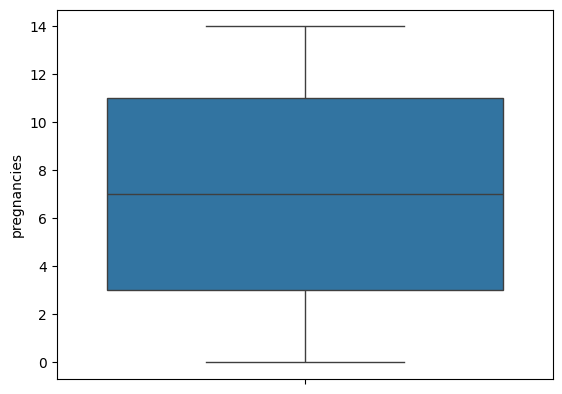

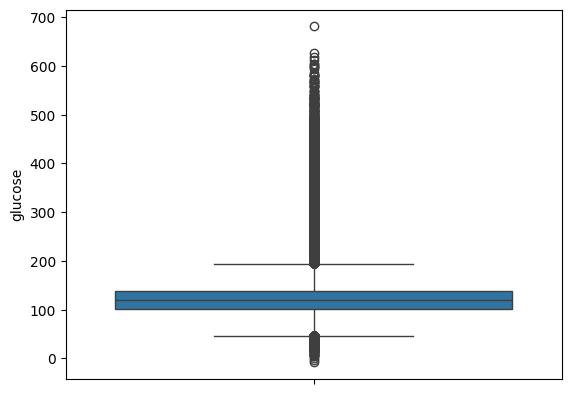

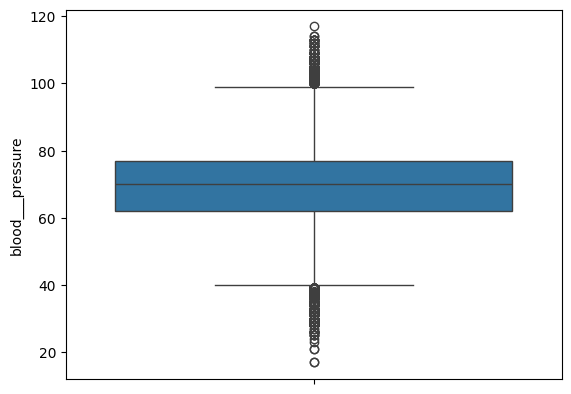

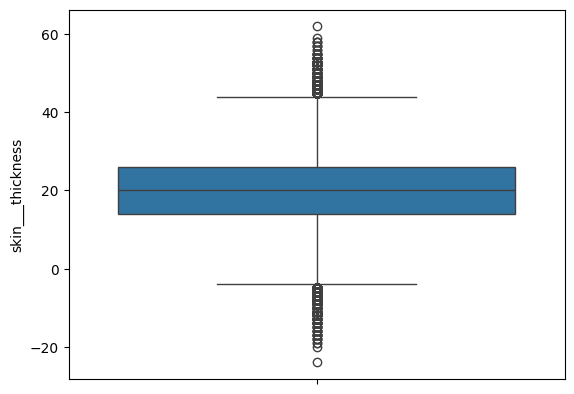

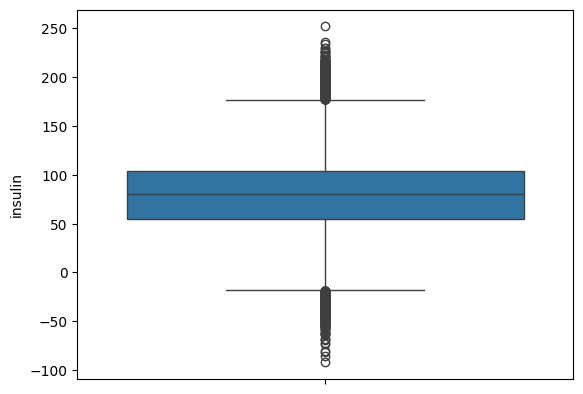

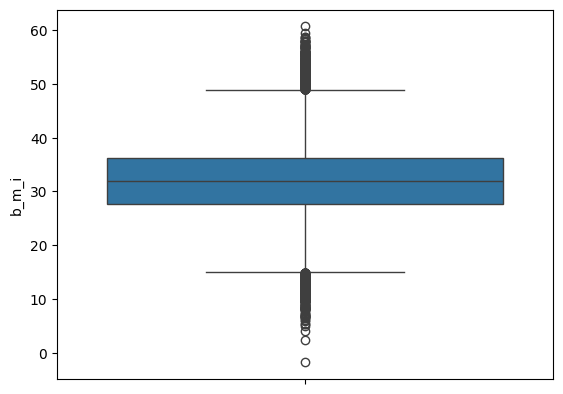

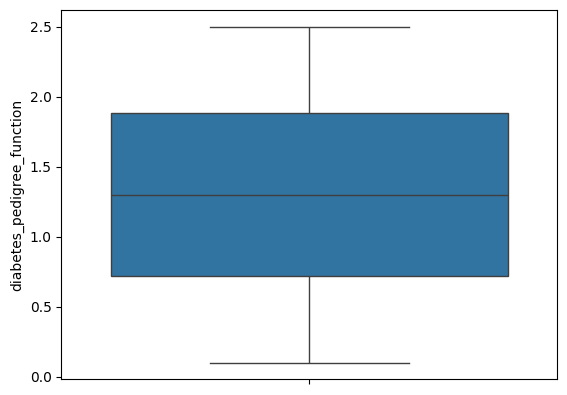

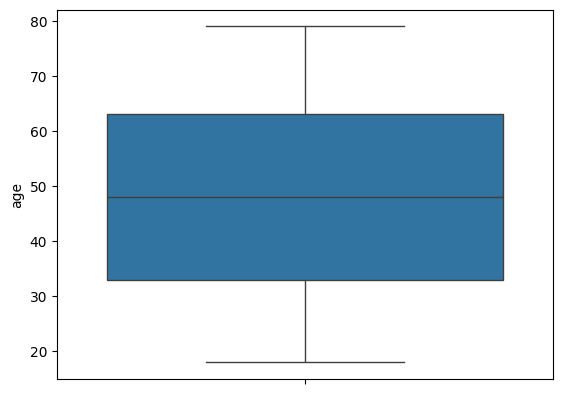

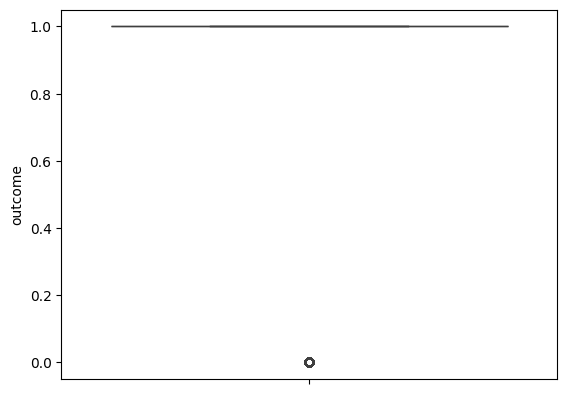

In [18]:
for i in data.columns:
    
    sns.boxplot(data[i])
    plt.show()

In [19]:
def outlier_treat(d):
    q1 = d.quantile(0.25)
    q3 = d.quantile(0.75)
    iqr = (q3- q1)

    uc = q3 + 1.5 * iqr
    lc = q1 - 1.5 * iqr
    return lc, uc

In [20]:
col = ['glucose', 'blood___pressure', 'skin___thickness', 'insulin', 'b_m_i']
for i in col:
    lc, uc = outlier_treat(data[i])

    data[i] = data[i].clip(lc,uc)

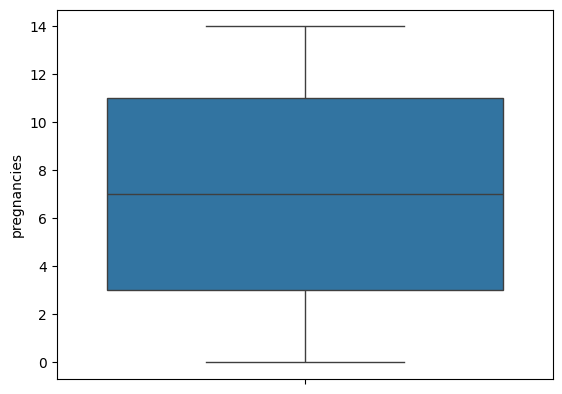

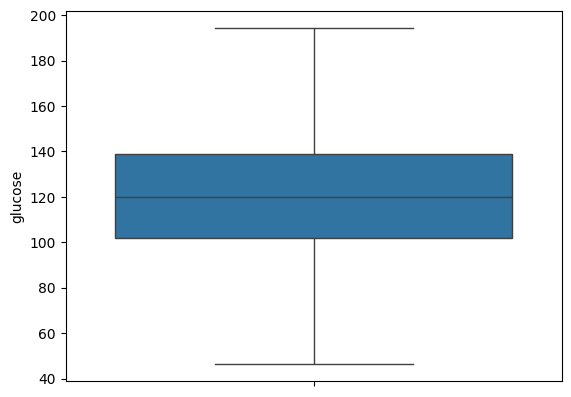

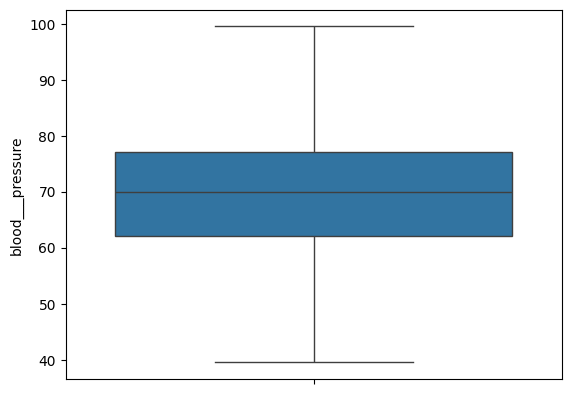

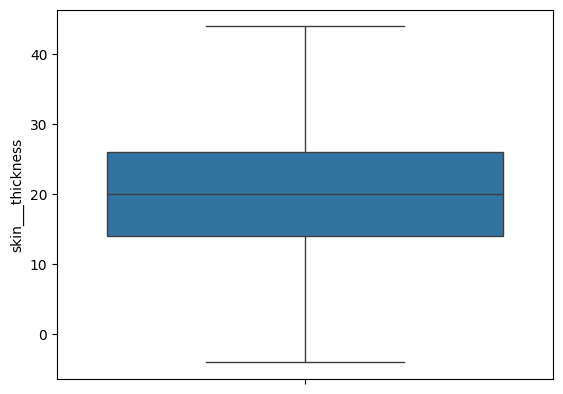

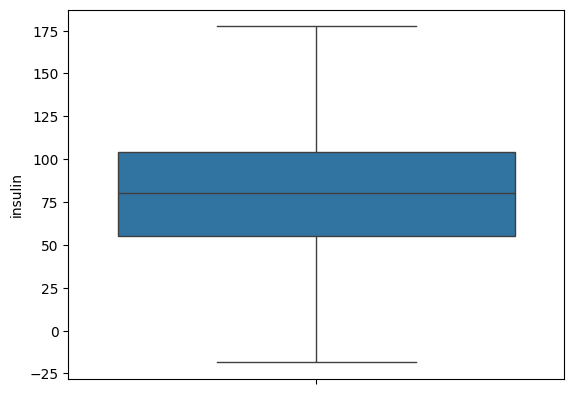

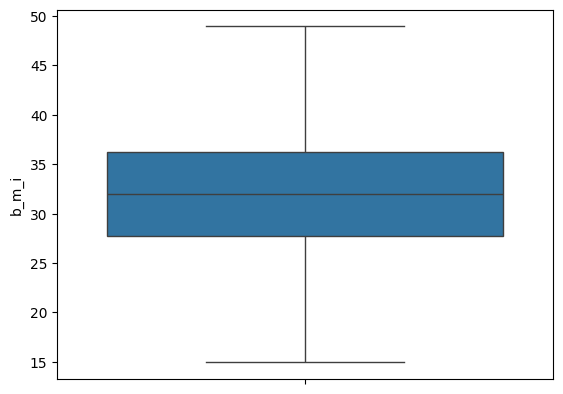

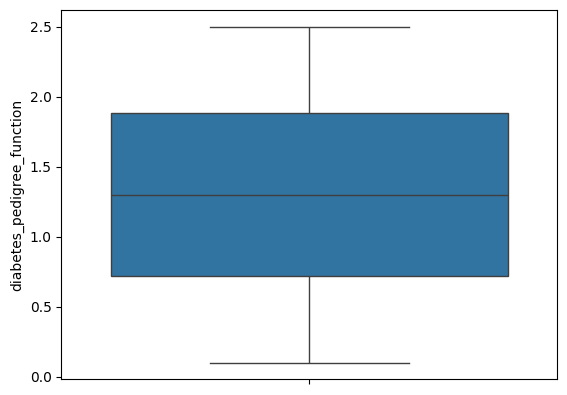

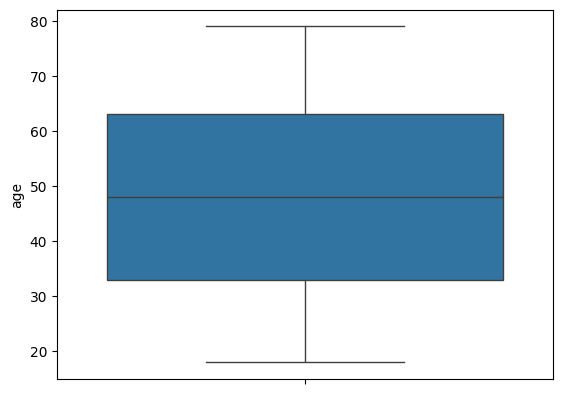

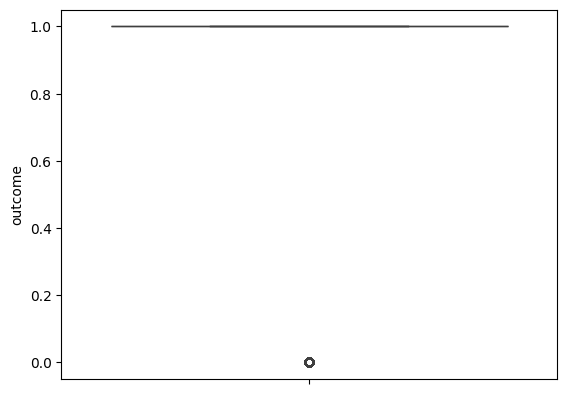

In [21]:
for i in data.columns:
    sns.boxplot(data[i])
    plt.show()

## 1.7 Feature Scaling

Since SVM is a distance-based algorithm, feature scaling is essential.

We use StandardScaler to normalize the data so that all features contribute equally to the model.

In [22]:
from sklearn.preprocessing import StandardScaler

ss= StandardScaler()

In [23]:
# Splitting the data

X = data.drop(columns = ['outcome'])
y = data['outcome']

In [24]:
X.head()

,pregnancies,glucose,blood___pressure,skin___thickness,insulin,b_m_i,diabetes_pedigree_function,age
0,6.0,144.0,71.0,18.0,85.0,28.6,2.370,61.0
1,3.0,194.5,67.0,8.0,100.0,22.1,2.317,23.0
2,12.0,114.0,66.0,24.0,116.0,32.0,1.240,48.0
3,14.0,114.0,51.0,17.0,18.0,22.4,1.714,36.0
4,10.0,136.0,74.0,22.0,91.0,33.8,0.537,41.0


In [25]:
X.shape

(100000, 8)

In [26]:
y.shape

(100000,)

In [27]:
X_scaled = ss.fit_transform(X)

# Step 2: Exploratory Data Analysis (EDA)

In this step, we analyze the dataset to understand patterns, relationships, and key factors influencing diabetes.

EDA helps in:
- Identifying important features
- Understanding distributions
- Detecting patterns between variables
- Supporting model selection

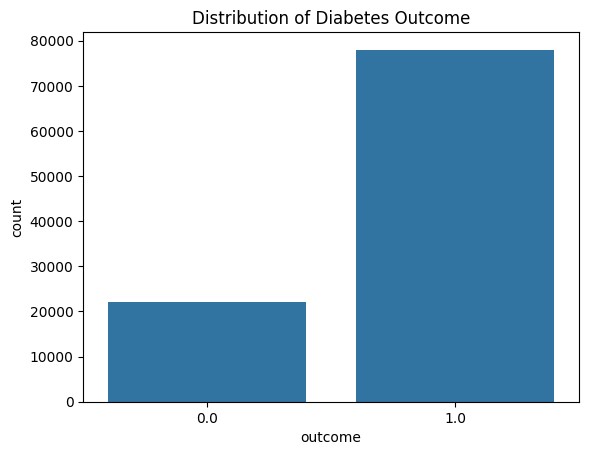

In [28]:
sns.countplot(x='outcome', data=data)
plt.title("Distribution of Diabetes Outcome")
plt.show()

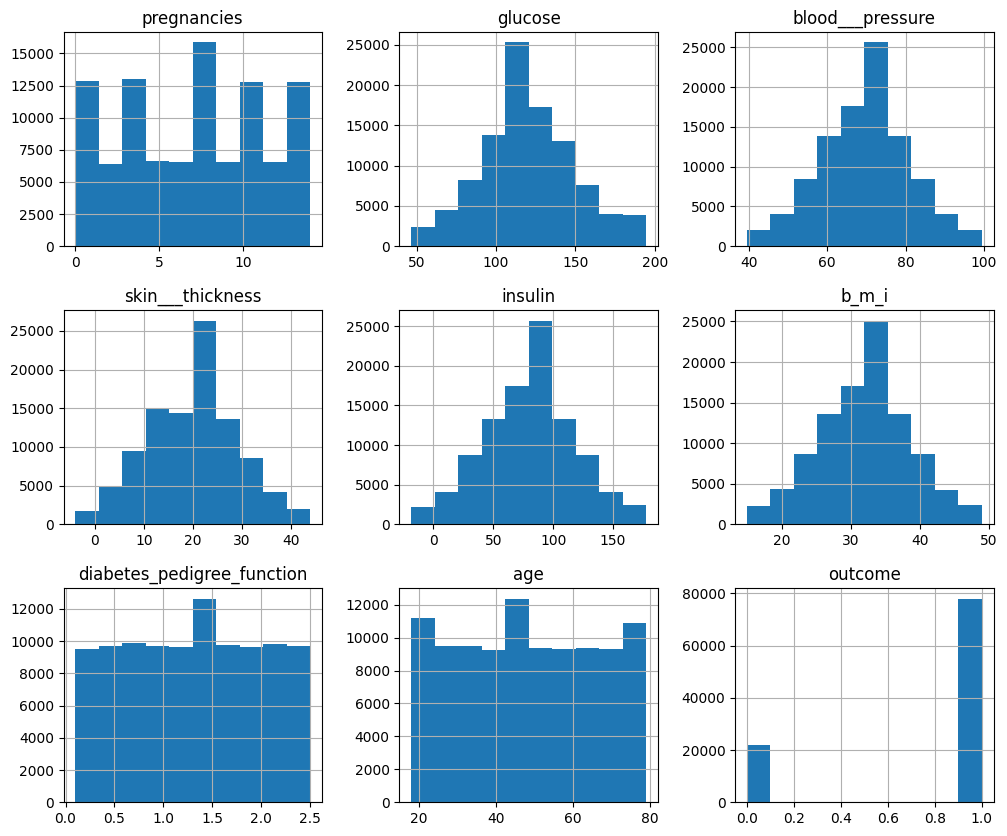

In [29]:
data.hist(figsize=(12,10))
plt.show()

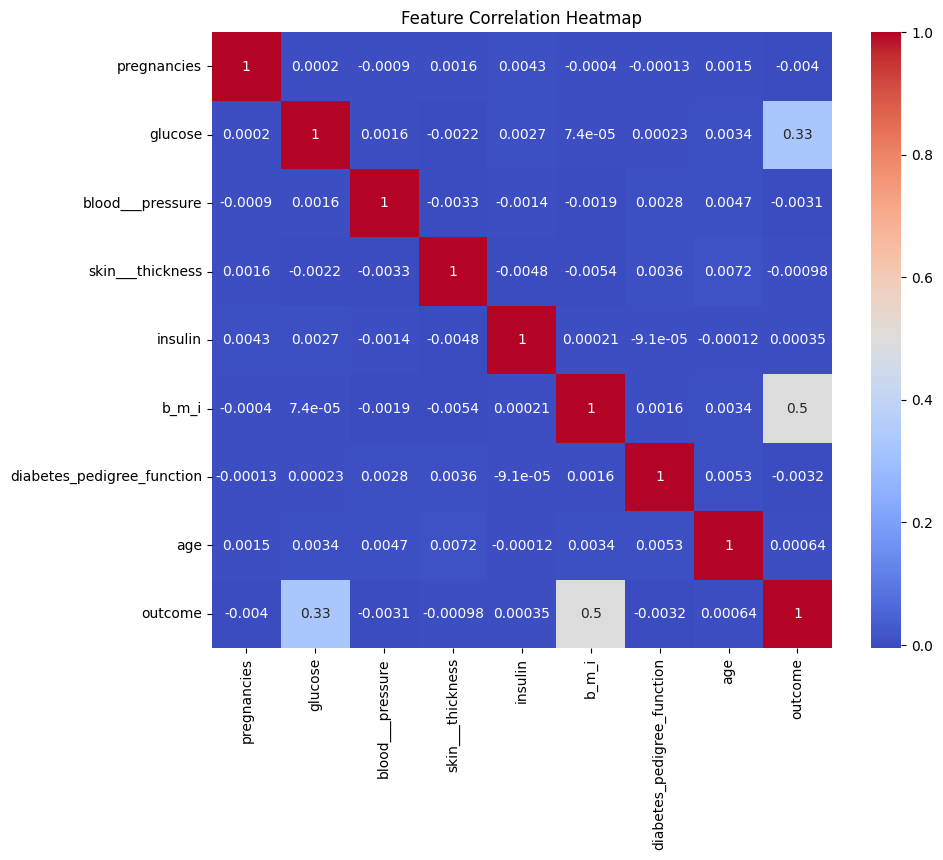

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Key Insights from EDA

- BMI and Glucose show significant impact
- Some features show weak correlation and may not contribute much

# Step 3: Model Building and Evaluation

In this step, we train multiple machine learning models to predict diabetes.

We compare different algorithms to identify the best-performing model.

Models used:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

## 3.1 Train-Test Split

We split the dataset into training and testing sets.

- 80% data for training
- 20% data for testing

This ensures the model is evaluated on unseen data.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 3.2 Model Training

We train multiple models and compare their performance.

This helps in selecting the most suitable algorithm for the dataset.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = score

results

{'Logistic Regression': 0.8632,
 'Decision Tree': 0.9445,
 'Random Forest': 0.9586,
 'SVM': 0.9352}

## 3.3 Model Evaluation

We evaluate the model using:

- Confusion Matrix
- Precision
- Recall
- F1-score

These metrics give a better understanding than accuracy alone.

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 3604   812]
 [  484 15100]]
              precision    recall  f1-score   support

         0.0       0.88      0.82      0.85      4416
         1.0       0.95      0.97      0.96     15584

    accuracy                           0.94     20000
   macro avg       0.92      0.89      0.90     20000
weighted avg       0.93      0.94      0.93     20000



# Step 4: Hyperparameter Tuning

In this step, we optimize the performance of the Support Vector Machine (SVM) model.

Instead of using default parameters, we use GridSearchCV to find the best combination of hyperparameters.

This helps in improving model accuracy and generalization.

## 4.1 Hyperparameter Tuning using GridSearchCV

We tune the following SVM parameters:

- C: Controls regularization
- Kernel: Defines decision boundary (linear or rbf)
- Gamma: Controls influence of data points

We use F1-score as the evaluation metric due to class imbalance.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
}

grid = GridSearchCV(
    SVC(gamma = 'auto'),
    param_grid,
    cv=3,
    scoring='f1',   # IMPORTANT (because imbalance)
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(gamma='auto')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

## 4.2 Best Parameters

GridSearchCV provides the optimal combination of hyperparameters that maximize model performance.

In [37]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best Score: 0.9619333061900722


## 4.3 Final Model Evaluation

We evaluate the optimized model using:
- Confusion Matrix
- Precision
- Recall
- F1-score

This ensures the model performs well on unseen data.

In [38]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 3699   717]
 [  513 15071]]
              precision    recall  f1-score   support

         0.0       0.88      0.84      0.86      4416
         1.0       0.95      0.97      0.96     15584

    accuracy                           0.94     20000
   macro avg       0.92      0.90      0.91     20000
weighted avg       0.94      0.94      0.94     20000



## Step 5 : Model Saving

The trained SVM model is saved using pickle so that it can be reused without retraining.

This is useful for deployment and real-world applications.

In [40]:
import pickle

with open("svm_diabetes_model.pkl", "wb") as f:
    pickle.dump(best_model, f)